In [41]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, List, Annotated
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
import operator
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI

In [42]:
load_dotenv()

True

In [43]:
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen3-32B",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

In [44]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Feedback for the essay")
    score: int = Field(description="Score for the essay", ge=0, le=10)
    

In [45]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

structured_model = model.with_structured_output(
    EvaluationSchema
)

In [46]:
class UPSCEssayState(TypedDict):
    essay: str
    CoT_feedback: str
    Grammar_feedback: str
    Factual_feedback: str
    final_feedback: str

    scores: Annotated[List[int], operator.add]
    final_score: float

In [47]:
def Factual_Evaluator(state: UPSCEssayState) -> UPSCEssayState:
    essay = state["essay"]
    prompt = f"Evaluate the following essay for factual accuracy and provide feedback:\n\n{essay}"
    response = structured_model.invoke(prompt)
    state["Factual_feedback"] = response.feedback
    return {"Factual_feedback": response.feedback, "scores": [response.score]}

def CoT_Evaluator(state: UPSCEssayState) -> UPSCEssayState:
    essay = state["essay"]
    prompt = f"Evaluate the following essay for clarity of thought and provide feedback:\n\n{essay}"
    response = structured_model.invoke(prompt)
    state["CoT_feedback"] = response.feedback
    return {"CoT_feedback": response.feedback, "scores": [response.score]}
def Grammar_Evaluator(state: UPSCEssayState) -> UPSCEssayState:
    essay = state["essay"]
    prompt = f"Evaluate the following essay for grammar and provide feedback:\n\n{essay}"
    response = structured_model.invoke(prompt)
    state["Grammar_feedback"] = response.feedback
    return {"Grammar_feedback": response.feedback, "scores": [response.score]}
def final_Evaluator(state: UPSCEssayState) -> UPSCEssayState:
    essay = state["essay"]
    prompt = f"Evaluate the following essay based on the feedback provided and give a final score based on {state['scores']} which is just the average of the three scores provided inside the list, :\n\nEssay:\n{essay}\n\nCoT Feedback:\n{state['CoT_feedback']}\n\nGrammar Feedback:\n{state['Grammar_feedback']}\n\nFactual Feedback:\n{state['Factual_feedback']}"
    response = structured_model.invoke(prompt)
    state["final_feedback"] = response.feedback
    state["final_score"] = response.score
    return {"final_feedback": response.feedback, "final_score": response.score}

In [48]:
graph = StateGraph(UPSCEssayState)

# add nodes
graph.add_node("Factual_evaluation", Factual_Evaluator)
graph.add_node("CoT_evaluation", CoT_Evaluator)
graph.add_node("Grammar_evaluation", Grammar_Evaluator)
graph.add_node("Final_evaluation",final_Evaluator)
# add edges
graph.add_edge(START, "Factual_evaluation")
graph.add_edge(START, "CoT_evaluation")
graph.add_edge(START, "Grammar_evaluation")
graph.add_edge("Factual_evaluation", "Final_evaluation")
graph.add_edge("CoT_evaluation", "Final_evaluation")
graph.add_edge("Grammar_evaluation", "Final_evaluation")
graph.add_edge("Final_evaluation", END)
# compile
workflow = graph.compile()

In [49]:
essay2 = """India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

India must all people together – govern, school, company and normal people. We teach AI and make sure AI not bad. Also talk to other country and learn from them.

If India use AI good way, we become strong, help poor and make better life. But if only rich use AI, and poor no get, then big bad thing happen.

So, in short, AI time in India have many hope and many danger. We must go right road. AI must help all people, not only some. Then India grow big and world say "good job India"."""

In [50]:
intial_state = {
    'essay': essay2,
    'scores': []
}

final_state = workflow.invoke(intial_state)
print(final_state['scores'])
print(final_state['final_score'])

[5, 7, 4]
5


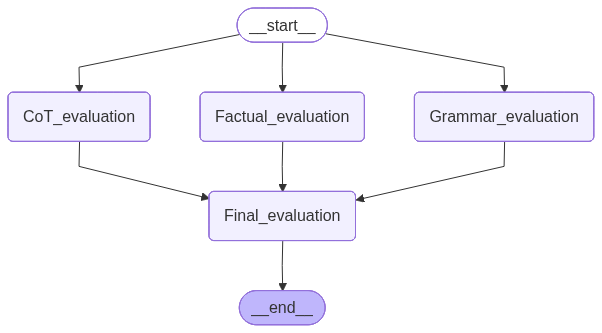

In [51]:
workflow